<div dir="rtl" style="text-align:right;">

<h2 style="color:blue;">پروژه تحلیل و ترکیب داده‌های Country و City</h2>

در این پروژه، سه فایل CSV شامل اطلاعات کشورها، شهرها و زبان‌های کشورها با استفاده از Pandas وارد می‌شوند. سپس با استفاده از عملیات مختلف Join مانند LEFT JOIN، RIGHT JOIN و INNER JOIN، اطلاعات موجود در این فایل‌ها با یکدیگر ترکیب شده و جداول موردنظر استخراج می‌شوند.

</div>

<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">وارد کردن کتابخانه‌ها</h4>

در این بخش کتابخانه Pandas برای خواندن، مدیریت و ترکیب داده‌ها وارد می‌شود.

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">بارگذاری فایل‌های CSV</h4>

در این مرحله سه فایل CSV شامل اطلاعات کشورها، شهرها و زبان‌های کشورها وارد محیط پایتون می‌شوند تا برای تحلیل و ترکیب داده‌ها مورد استفاده قرار گیرند.

</div>

In [3]:
path = r"C:\Users\ASUS\Desktop"

country = pd.read_csv(path + r"\country.csv")
city = pd.read_csv(path + r"\city.csv")
country_language = pd.read_csv(path + r"\country_language.csv")

<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">مشاهده ۵ ردیف اول داده‌ها</h4>

در این مرحله، برای بررسی اولیه ساختار داده‌ها، ۵ ردیف اول هر یک از سه فایل CSV را مشاهده می‌کنیم. این کار به ما کمک می‌کند نام ستون‌ها، نوع اطلاعات و ارتباط احتمالی بین جدول‌ها را بررسی کنیم.

</div>

In [5]:
print("Country")
display(country.head())

print("City")
display(city.head())

print("Country Language")
display(country_language.head())

Country


,Unnamed: 0,Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
0,0,ABW,Aruba,North America,Caribbean,193.0,NaN,103000,78.4,828.0,793.0,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix,129.0,AW
1,1,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919.0,22720000,45.9,5976.0,NaN,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar,1.0,AF
2,2,AGO,Angola,Africa,Central Africa,1246700.0,1975.0,12878000,38.3,6648.0,7984.0,Angola,Republic,José Eduardo dos Santos,56.0,AO
3,3,AIA,Anguilla,North America,Caribbean,96.0,NaN,8000,76.1,63.2,NaN,Anguilla,Dependent Territory of the UK,Elisabeth II,62.0,AI
4,4,ALB,Albania,Europe,Southern Europe,28748.0,1912.0,3401200,71.6,3205.0,2500.0,Shqipëria,Republic,Rexhep Mejdani,34.0,AL


City


,Unnamed: 0,ID,Name,CountryCode,District,Population
0,0,1,Kabul,AFG,Kabol,1780000
1,1,2,Qandahar,AFG,Qandahar,237500
2,2,3,Herat,AFG,Herat,186800
3,3,4,Mazar-e-Sharif,AFG,Balkh,127800
4,4,5,Amsterdam,NLD,Noord-Holland,731200


Country Language


,Unnamed: 0,CountryCode,Language,IsOfficial,Percentage
0,0,ABW,Dutch,T,5.3
1,1,ABW,English,F,9.5
2,2,ABW,Papiamento,F,76.7
3,3,ABW,Spanish,F,7.4
4,4,AFG,Balochi,F,0.9


<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">محاسبه پرکاربردترین زبان کشورهای آسیایی</h4>

در این مرحله، کشورهای آسیایی انتخاب می‌شوند و برای هر کشور زبانی که بیشترین درصد گویش را دارد مشخص می‌شود. سپس با استفاده از جمعیت کشور و درصد گویش تعداد تقریبی افرادی که به آن زبان صحبت می‌کنند محاسبه می‌شود.

</div>

In [12]:
# انتخاب کشورهای آسیایی
asia = country[country["Continent"] == "Asia"].copy()

# پیدا کردن زبان با بیشترین درصد برای هر کشور
lang_max = country_language.loc[
    country_language.groupby("CountryCode")["Percentage"].idxmax()
].copy()

# اتصال کشور و زبان
table1 = asia.merge(
    lang_max,
    left_on="Code",
    right_on="CountryCode",
    how="inner"
)

# محاسبه تعداد افراد گویشور
table1["Number_of_Speakers"] = (
    table1["Population"] * table1["Percentage"] / 100
).round().astype("Int64")

# انتخاب ستون‌های نهایی
table1 = table1[
    ["Name", "Language", "Number_of_Speakers"]
].rename(columns={
    "Name": "Country",
    "Language": "Most_Common_Language"
})

table1

,Country,Most_Common_Language,Number_of_Speakers
0,Afghanistan,Pashto,11905280
1,United Arab Emirates,Arabic,1025220
2,Armenia,Armenian,3287680
3,Azerbaijan,Azerbaijani,6883260
4,Bangladesh,Bengali,126184435
5,Bahrain,Arabic,417709
6,Brunei,Malay,149240
7,Bhutan,Dzongkha,1062000
8,China,Chinese,1175353360
9,Cyprus,Greek,559233


<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">نمودار دایره‌ای زبان‌های پرکاربرد</h4>

در این نمودار، زبان‌های پرکاربرد کشورهای آسیایی و تعداد کشورهایی که هر زبان به عنوان زبان پرکاربرد آن‌ها انتخاب شده است نمایش داده می‌شود.

</div>

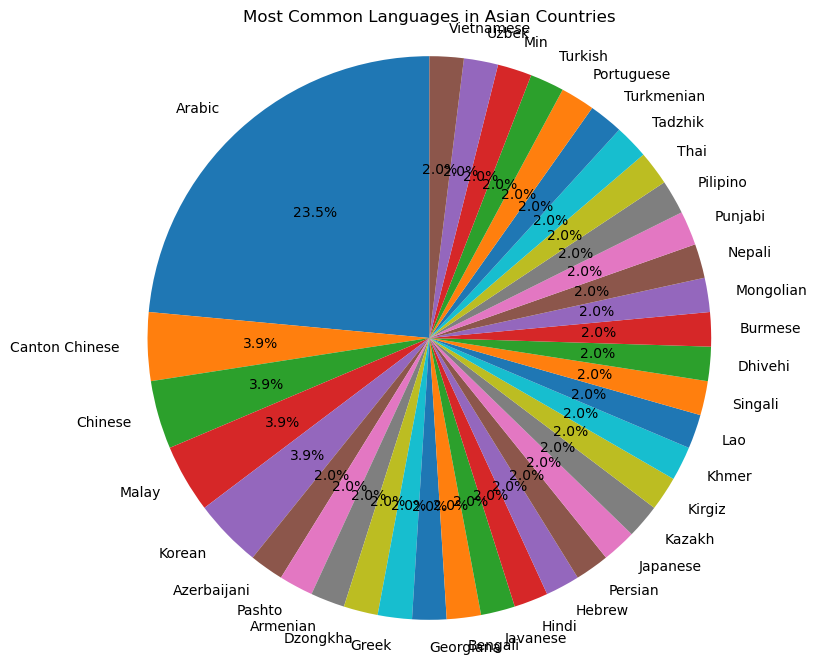

In [13]:
import matplotlib.pyplot as plt

language_counts = table1["Most_Common_Language"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    language_counts.values,
    labels=language_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Most Common Languages in Asian Countries")
plt.axis("equal")
plt.show()

<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">تمرین دوم: پرجمعیت‌ترین شهر هر کشور</h4>

در این تمرین، جدول‌های <b>Country</b> و <b>City</b> با استفاده از کد کشور به یکدیگر متصل می‌شوند.

از آنجا که هر کشور می‌تواند چندین شهر داشته باشد، پس از اتصال دو جدول، شهرهای هر کشور بر اساس جمعیت بررسی شده و پرجمعیت‌ترین شهر هر کشور انتخاب می‌شود.

</div>

In [14]:
# اتصال جدول Country و City بر اساس کد کشور
country_city = country.merge(
    city,
    left_on="Code",
    right_on="CountryCode",
    how="inner"
)

# مرتب‌سازی شهرها بر اساس جمعیت، از بیشترین به کمترین
country_city = country_city.sort_values(
    "Population_y",
    ascending=False
)

# انتخاب پرجمعیت‌ترین شهر هر کشور
table2 = country_city.drop_duplicates(
    subset="Code",
    keep="first"
)

# انتخاب ستون‌های موردنیاز
table2 = table2[
    ["Name_x", "Name_y", "Population_y"]
].rename(columns={
    "Name_x": "Country",
    "Name_y": "City",
    "Population_y": "Population"
})

table2

,Country,City,Population
1520,India,Mumbai (Bombay),10500000
2311,South Korea,Seoul,9981619
191,Brazil,São Paulo,9968485
532,China,Shanghai,9696300
1435,Indonesia,Jakarta,9604900
...,...,...,...
2758,Niue,Alofi,682
496,Cocos (Keeling) Islands,Bantam,503
3938,Holy See (Vatican City State),Città del Vaticano,455
3456,Tokelau,Fakaofo,300


<div dir="rtl" style="text-align:right;">

<h5 style="color:blue;">بررسی پایتخت بودن پرجمعیت‌ترین شهر</h5>

در این مرحله بررسی می‌کنیم که آیا پرجمعیت‌ترین شهر هر کشور، همان پایتخت آن کشور است یا خیر.

</div>

In [17]:
# انتخاب پرجمعیت‌ترین شهر هر کشور
table2 = country_city.sort_values(
    "Population_y",
    ascending=False
).drop_duplicates(
    subset="Code",
    keep="first"
).copy()

# بررسی اینکه آیا شهر انتخاب‌شده پایتخت کشور است یا خیر
# ID شهر با Capital کشور مقایسه می‌شود
table2["Is_Capital"] = (
    table2["ID"] == table2["Capital"]
)

# انتخاب ستون‌های موردنیاز
table2 = table2[
    ["Name_x", "Name_y", "Population_y", "Is_Capital"]
].rename(columns={
    "Name_x": "Country",
    "Name_y": "City",
    "Population_y": "Population"
})

table2

,Country,City,Population,Is_Capital
1520,India,Mumbai (Bombay),10500000,False
2311,South Korea,Seoul,9981619,True
191,Brazil,São Paulo,9968485,False
532,China,Shanghai,9696300,False
1435,Indonesia,Jakarta,9604900,True
...,...,...,...,...
2758,Niue,Alofi,682,True
496,Cocos (Keeling) Islands,Bantam,503,False
3938,Holy See (Vatican City State),Città del Vaticano,455,True
3456,Tokelau,Fakaofo,300,True


<div dir="rtl" style="text-align:right;">

<h4 style="color:blue;">تمرین سوم: اطلاعات کشور، پایتخت و زبان رسمی</h4>

در این تمرین، اطلاعات سه جدول <b>Country</b>، <b>City</b> و <b>Country Language</b> با استفاده از کلیدهای مرتبط با یکدیگر ترکیب می‌شوند.

برای پیدا کردن پایتخت، ستون <b>Capital</b> از جدول Country به ستون <b>ID</b> در جدول City متصل می‌شود.

برای پیدا کردن زبان‌های رسمی نیز کشورهایی که مقدار <b>IsOfficial</b> آن‌ها برابر با <b>T</b> است انتخاب می‌شوند.

اگر یک کشور بیش از یک زبان رسمی داشته باشد، تمام زبان‌های رسمی آن کشور نمایش داده می‌شوند.

</div>

In [23]:
# اتصال Country به City برای پیدا کردن پایتخت
country_capital = country.merge(
    city,
    left_on="Capital",
    right_on="ID",
    how="left",
    suffixes=("_country", "_city")
)

# انتخاب زبان‌های رسمی
official_languages = country_language[
    country_language["IsOfficial"] == "T"
].copy()

# گروه‌بندی زبان‌های رسمی هر کشور
# چند زبان رسمی داخل یک براکت قرار می‌گیرند
official_languages = (
    official_languages
    .groupby("CountryCode")["Language"]
    .apply(lambda x: "[" + ", ".join(x) + "]")
    .reset_index()
)

# اتصال زبان‌های رسمی به اطلاعات کشور و پایتخت
table3 = country_capital.merge(
    official_languages,
    left_on="Code",
    right_on="CountryCode",
    how="left"
)

# انتخاب ستون‌های موردنیاز
table3 = table3[
    ["Code", "Name_country", "Name_city",
     "Language", "Population_city"]
].rename(columns={
    "Name_country": "Country",
    "Name_city": "Capital",
    "Language": "Official_Languages",
    "Population_city": "Capital_Population"
})

table3 = table3.dropna(
    subset=["Code", "Country", "Capital",
            "Official_Languages", "Capital_Population"]
)

table3

,Code,Country,Capital,Official_Languages,Capital_Population
0,ABW,Aruba,Oranjestad,[Dutch],29034.0
1,AFG,Afghanistan,Kabul,"[Dari, Pashto]",1780000.0
3,AIA,Anguilla,The Valley,[English],595.0
4,ALB,Albania,Tirana,[Albaniana],270000.0
5,AND,Andorra,Andorra la Vella,[Catalan],21189.0
...,...,...,...,...,...
233,WSM,Samoa,Apia,"[English, Samoan]",35900.0
234,YEM,Yemen,Sanaa,[Arabic],503600.0
235,YUG,Yugoslavia,Beograd,[Serbo-Croatian],1204000.0
236,ZAF,South Africa,Pretoria,"[Afrikaans, English, Xhosa, Zulu]",658630.0
